# Rabbits and foxes - with diffusion

First, the original rabbits and foxes problem:

There are initially 400 rabbits and 200 foxes on a farm (but it could be two cell types in a 96 well plate or something, if you prefer bio-engineering analogies). Plot the concentration of foxes and rabbits as a function of time for a period of up to 600 days. The predator-prey relationships are given by the following set of coupled ordinary differential equations:

\begin{align}
\frac{dR}{dt} &= k_1 R - k_2 R F \tag{1}\\
\frac{dF}{dt} &= k_3 R F - k_4 F \tag{2}\\
\end{align}

* Constant for growth of rabbits $k_1 = 0.015$ day<sup>-1</sup>
* Constant for death of rabbits being eaten by foxes $k_2 = 0.00004$ day<sup>-1</sup> foxes<sup>-1</sup>
* Constant for growth of foxes after eating rabbits $k_3 = 0.0004$ day<sup>-1</sup> rabbits<sup>-1</sup>
* Constant for death of foxes $k_4 = 0.04$ day<sup>-1</sup>

*This problem is based on one from Chapter 1 of H. Scott Fogler's textbook "Essentials of Chemical Reaction Engineering".*


In [1]:
%matplotlib inline
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

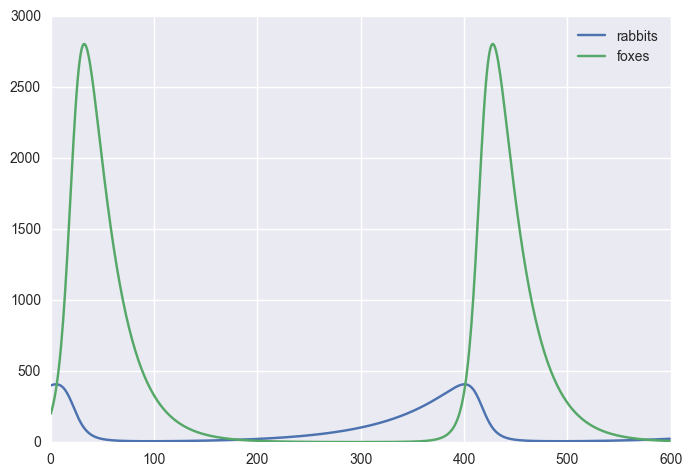

In [2]:
from scipy.integrate import odeint

k1 = 0.015
k2 = 0.00004
k3 = 0.0004
k4 = 0.04
end_time = 600.

def rates(variables, time):
    """
    Return the right hand side of the ODE
    """
    rabbits, foxes = variables
    rate_rabbits = (k1 * rabbits - k2 * rabbits * foxes)
    rate_foxes = (k3 * rabbits * foxes - k4 * foxes)
    return (rate_rabbits, rate_foxes)

times = np.arange(0, end_time)
initial_conditions = (400., 200.)
result = odeint(rates, initial_conditions, times)
rabbits = result[:,0]
foxes = result[:,1]
plt.plot(times, rabbits, label='rabbits')
plt.plot(times, foxes, label='foxes')
plt.legend(loc="best") # put the legend at the best location to avoid overlapping things
plt.show()

# Reaction and diffusion
Now set it up for diffusion on a grid of farms.

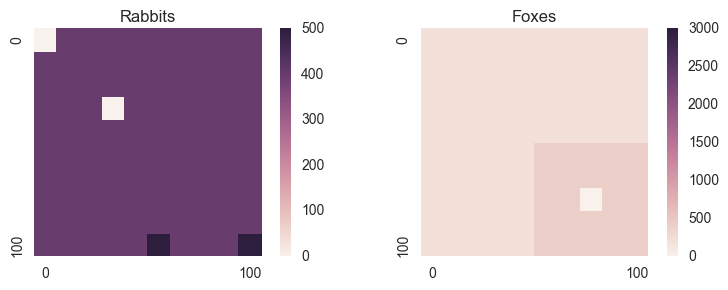

In [76]:
x_max = y_max = 100
N = M = 10
dx = x_max / (N-1)
dy = y_max / (M-1)
xgrid = np.linspace(0,x_max,N)
ygrid = np.linspace(0,y_max,M)
assert dx == xgrid[1]

diffusivity_rabbits = 1e-3
diffusivity_foxes = 1e-3


concentrations = np.ones((2,N,M)) 
#concentrations += 0.5 * np.abs(np.random.randn(2,N,M))
concentrations[0] *= 400
concentrations[1] *= 200
concentrations[1,N//2:,M//2:] *= 2.0 # double foxes in top corner 
concentrations[0,3,3] = 0 # a dead spot of rabbits
concentrations[1,7,7] = 0 # a dead spot of foxes
concentrations[0,-1,-5] = 800 # a load of rabbits near one corner
concentrations[0,-1,-1] = 800 # a load of rabbits in one corner
concentrations[0,0,0] = 0 # a dead spot of rabbits at the origin

rabbits = concentrations[0]
foxes = concentrations[1]

plt.subplot(2,2,1)
xticklabels = [0] + ['']*(N-2) + [x_max]
yticklabels = [0] + ['']*(M-2) + [y_max]
sns.heatmap(rabbits, vmin=0, vmax=500, square=True,
            xticklabels=xticklabels, yticklabels=yticklabels)
plt.title('Rabbits')
plt.subplot(2,2,2)
sns.heatmap(foxes, vmin=0, vmax=3000, square=True,
            xticklabels=xticklabels, yticklabels=yticklabels)
plt.title('Foxes')
plt.tight_layout()
plt.show()

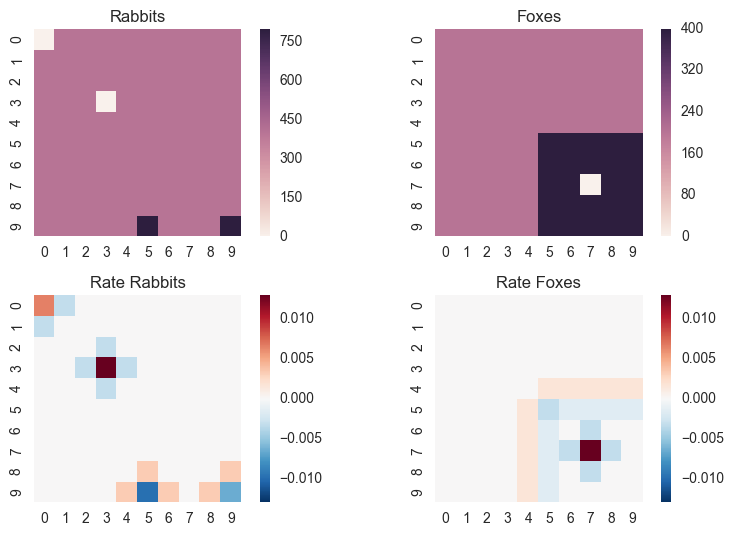

[[[ 0.00648 -0.00324  0.       0.       0.       0.       0.       0.       0.
    0.     ]
  [-0.00324  0.       0.       0.       0.       0.       0.       0.       0.
    0.     ]
  [ 0.       0.       0.      -0.00324  0.       0.       0.       0.       0.
    0.     ]
  [ 0.       0.      -0.00324  0.01296 -0.00324  0.       0.       0.       0.
    0.     ]
  [ 0.       0.       0.      -0.00324  0.       0.       0.       0.       0.
    0.     ]
  [ 0.       0.       0.       0.       0.       0.       0.       0.       0.
    0.     ]
  [ 0.       0.       0.       0.       0.       0.       0.       0.       0.
    0.     ]
  [ 0.       0.       0.       0.       0.       0.       0.       0.       0.
    0.     ]
  [ 0.       0.       0.       0.       0.       0.00324  0.       0.       0.
    0.00324]
  [ 0.       0.       0.       0.       0.00324 -0.00972  0.00324  0.
    0.00324 -0.00648]]

 [[ 0.       0.       0.       0.       0.       0.       0.       0.       0.

In [77]:
# Some practice while I figure things out 
concentrations_vector  = concentrations.reshape(-1)
concentrations = concentrations_vector.reshape((2,N,M))

rabbits = concentrations[0]
foxes = concentrations[1]

d2cdx2 = np.diff(concentrations, n=2, axis=1)
d2cdy2 = np.diff(concentrations, n=2, axis=2)

rate_rabbits = (k1 * rabbits - k2 * rabbits * foxes) *0
rate_foxes = (k3 * rabbits * foxes - k4 * foxes) *0

rate_rabbits[1:-1,:] += diffusivity_rabbits * d2cdx2[0] / (dx*dx)
rate_rabbits[:,1:-1] += diffusivity_rabbits * d2cdy2[0] / (dy*dy)
rate_rabbits[-1,:] += diffusivity_rabbits * (rabbits[-2,:] - rabbits[-1,:] ) / (dx*dx)
rate_rabbits[:,-1] += diffusivity_rabbits * (rabbits[:,-2] - rabbits[:,-1] ) / (dy*dy)
rate_rabbits[0,:] += diffusivity_rabbits * (rabbits[1,:] - rabbits[0,:] ) / (dx*dx)
rate_rabbits[:,0] += diffusivity_rabbits * (rabbits[:,1] - rabbits[:,0] ) / (dy*dy)

rate_foxes[1:-1,:] += diffusivity_foxes * d2cdx2[1] / (dx*dx)
rate_foxes[:,1:-1] += diffusivity_foxes * d2cdy2[1] / (dy*dy)
rate_foxes[-1,:] += diffusivity_foxes * (foxes[-2,:] - foxes[-1,:] ) / (dx*dx)
rate_foxes[:,-1] += diffusivity_foxes * (foxes[:,-2] - foxes[:,-1] ) / (dy*dy)
rate_foxes[0,:] += diffusivity_foxes * (foxes[1,:] - foxes[0,:] ) / (dx*dx)
rate_foxes[:,0] += diffusivity_foxes * (foxes[:,1] - foxes[:,0] ) / (dy*dy)


plt.subplot(2,2,1)
sns.heatmap(rabbits, square=True)
plt.title('Rabbits')
plt.subplot(2,2,3)
sns.heatmap(rate_rabbits, center=0, square=True)
plt.title('Rate Rabbits')
plt.tight_layout()

plt.subplot(2,2,2)
sns.heatmap(foxes, square=True)
plt.title('Foxes')
plt.subplot(2,2,4)
sns.heatmap(rate_foxes, center=0, square=True)
plt.title('Rate Foxes')

plt.show()

rates = np.stack((rate_rabbits, rate_foxes))
print(rates)

array([ 0.   ,  0.   ,  0.   ,  0.   ,  0.   , -0.036,  0.   ,  0.   ,
        0.   , -0.036])

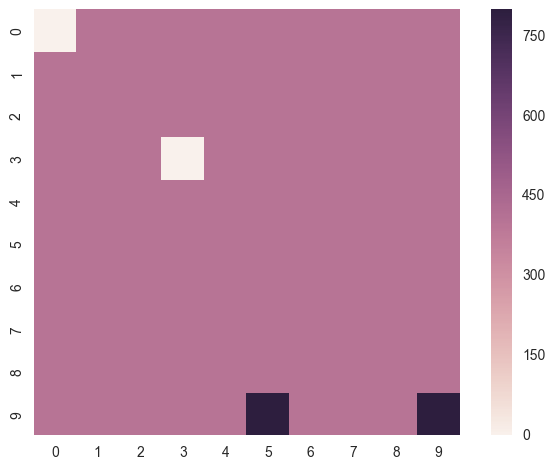

In [79]:
sns.heatmap(rabbits, square=True)
diffusivity * (rabbits[-2,:] - rabbits[-1,:] ) / dx

And now the differential equation version

In [80]:
%load_ext line_profiler
diffusivity = diffusivity_foxes
assert diffusivity_rabbits==diffusivity

def rates(concentrations_vector, time):
    """
    Return the right hand side of the ODE
    """
    concentrations = concentrations_vector.reshape((2,N,M))

    rabbits = concentrations[0]
    foxes = concentrations[1]
    d2cdx2 = np.diff(concentrations, n=2, axis=1)
    d2cdy2 = np.diff(concentrations, n=2, axis=2)

    rate_rabbits = (k1 * rabbits - k2 * rabbits * foxes)
    rate_foxes = (k3 * rabbits * foxes - k4 * foxes)
    rates = np.stack((rate_rabbits, rate_foxes))
    
    # Interior points
    rates[:,1:-1,:] += diffusivity * d2cdx2 / (dx*dx)
    rates[:,:,1:-1] += diffusivity * d2cdy2 / (dy*dy)
    # Boundaries
    rates[:, -1 ,  : ] += diffusivity * (concentrations[:,-2, :] - concentrations[:,-1, :] ) / (dx*dx)
    rates[:,  : , -1 ] += diffusivity * (concentrations[:, :,-2] - concentrations[:, :,-1] ) / (dy*dy)
    rates[:,  0 ,  : ] += diffusivity * (concentrations[:, 1, :] - concentrations[:, 0, :] ) / (dx*dx)
    rates[:,  : ,  0 ] += diffusivity * (concentrations[:, :, 1] - concentrations[:, :, 0] ) / (dy*dy)

    return rates.reshape(-1)

end_time = 4800
concentrations_vector  = concentrations.reshape(-1)
times = np.arange(0, end_time, 10)
initial_conditions = concentrations_vector
%lprun -f rates result = odeint(rates, initial_conditions, times)

print(result.shape)
results = result.reshape(-1,2,N,M)
print(results.shape)

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler
(480, 200)
(480, 2, 10, 10)


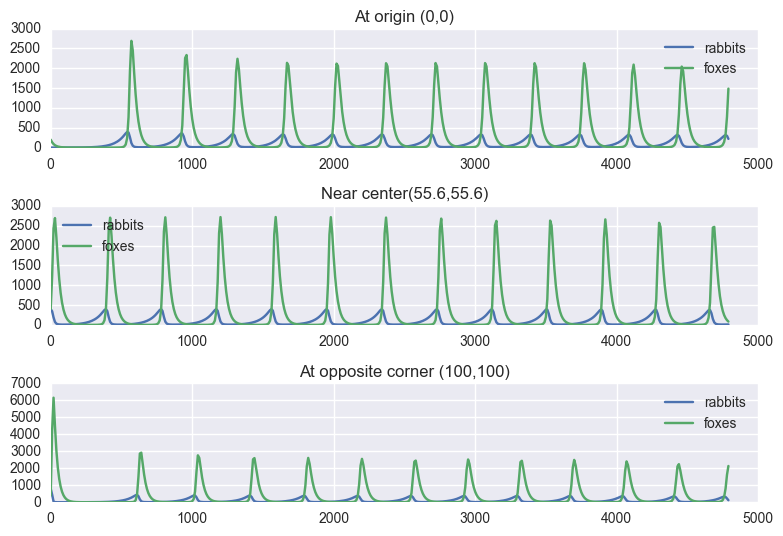

In [81]:
rabbits_origin = results[:,0,0,0]
foxes_origin = results[:,1,0,0]
plt.subplot(3,1,1)
plt.plot(times, rabbits_origin, label='rabbits')
plt.plot(times, foxes_origin, label='foxes')
plt.title("At origin (0,0)")
plt.legend(loc="best")

plt.subplot(3,1,2)
plt.plot(times, results[:,0,N//2,M//2], label='rabbits')
plt.plot(times, results[:,1,N//2,M//2], label='foxes')
plt.legend(loc="best") 
plt.title("Near center({:.1f},{:.1f})".format(xgrid[N//2],ygrid[M//2]))

plt.subplot(3,1,3)
plt.plot(times, results[:,0,-1,-1], label='rabbits')
plt.plot(times, results[:,1,-1,-1], label='foxes')
plt.legend(loc="best") 
plt.title("At opposite corner ({},{})".format(x_max,y_max))
plt.tight_layout()
plt.show()

At end time t=4800 days


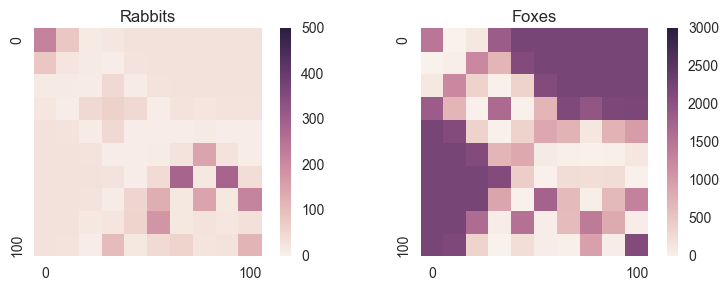

In [82]:
print('At end time t={} days'.format(end_time))
rabbits = results[-1,0]
foxes = results[-1,1]
fig = plt.figure()
plt.subplot(2,2,1)
sns.heatmap(rabbits, vmin=0, vmax=500, square=True,
           xticklabels=xticklabels, yticklabels=yticklabels)
plt.title('Rabbits')
plt.subplot(2,2,2)
sns.heatmap(foxes, vmin=0, vmax=3000, square=True,
           xticklabels=xticklabels, yticklabels=yticklabels)
plt.title('Foxes')
plt.tight_layout()
plt.show()

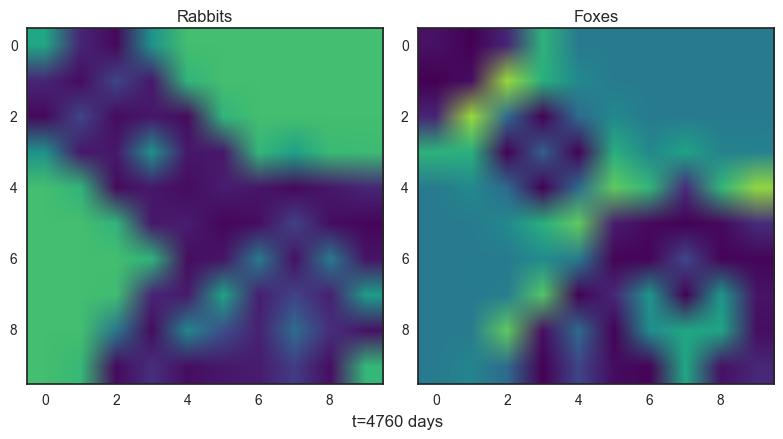

In [85]:
# Wondering if this is faster
from matplotlib import animation
import matplotlib
matplotlib.rc('animation', html='html5')
fig = plt.figure()
frames = 120

with sns.axes_style("white"):
    fig = plt.figure()
    ax1 = plt.subplot(1,2,1)
    ax1.set_title('Rabbits')
    ax2 = plt.subplot(1,2,2)
    ax2.set_title('Foxes')
    timestamp = fig.text(0.45,0.1,'timestamp')

im1 = ax1.imshow(results[0,0], cmap=plt.get_cmap('viridis'), animated=True, vmin=0, vmax=500)
im2 = ax2.imshow(results[0,1], cmap=plt.get_cmap('viridis'), animated=True, vmin=0, vmax=3000)
plt.tight_layout()

def animate(i):
    timestep = i * len(times)//(frames)
    im1.set_array(results[timestep,0])
    im2.set_array(results[timestep,1])
    timestamp.set_text('t={0:.0f} days'.format(times[timestep]))
    return im1, im2, 
    
anim = animation.FuncAnimation(fig, animate, frames=frames, 
                               repeat_delay=2000, repeat=True,
                              interval=50, blit=True)
anim.save('rabbits-and-foxes.mp4', bitrate=1500)
True
anim

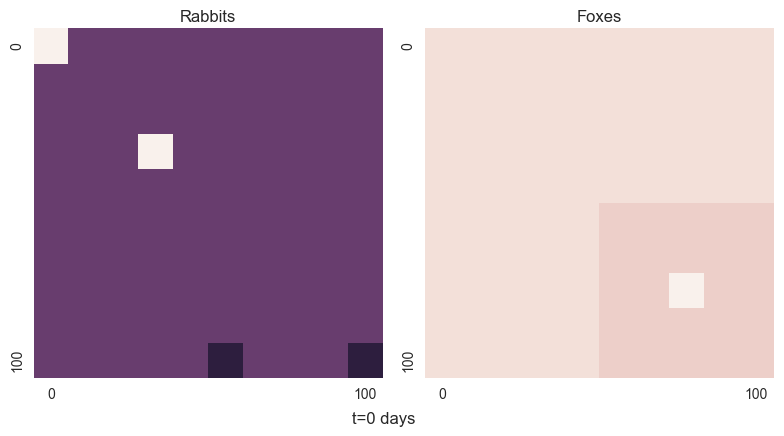

In [84]:
from matplotlib import animation
import matplotlib
matplotlib.rc('animation', html='html5')
fig = plt.figure()
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)
timestamp = fig.text(0.45,0.1,'timestamp')
frames = 120

def animate(i):
    timestep = i * len(times)//(frames)
    rabbits = results[timestep,0]
    foxes = results[timestep,1]
    sns.heatmap(rabbits, square=True, vmin=0, vmax=500, ax=ax1, cbar=None,
               xticklabels=xticklabels, yticklabels=yticklabels)
    ax1.set_title('Rabbits')
    sns.heatmap(foxes, square=True, vmin=0, vmax=3000, ax=ax2, cbar=None,
               xticklabels=xticklabels, yticklabels=yticklabels)
    ax2.set_title('Foxes')
    timestamp.set_text('t={0:.0f} days'.format(times[timestep]))
    plt.tight_layout()

## Commented out because this version is slow
anim = animation.FuncAnimation(fig, animate, frames=frames, 
                               repeat_delay=2000, repeat=True,
                              interval=50,)
#anim.save('rabbits_and_foxes.mp4', bitrate=1500)
anim

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ..., 
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

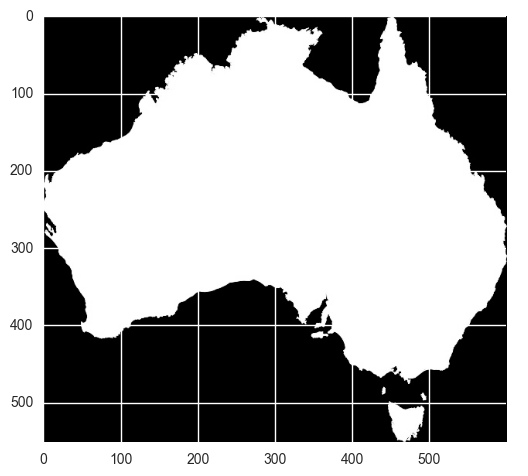

In [10]:
import urllib
import scipy.ndimage
image_file = urllib.request.urlopen('http://images.all-free-download.com/images/graphiclarge/australian_maps_clip_art_15441.jpg')
australia = scipy.ndimage.imread(image_file, mode='L')
plt.imshow(australia)
1-australia//255